In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("ipl.csv")

df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


IPL 2022 Capstone Project
The Indian Premier League (IPL) is a professional T20 cricket league in India, featuring franchises representing cities. This project explores IPL 2022 match-level data to derive meaningful insights and understand match outcomes, player performances, and team dynamics.

These are some of the important columns that we'll focus on for meaningful insights in this project.

column names: Variable Type

date : string
venue : string
stage : string
team1 : string
team2 : string
toss_winner : string
toss_decision : string
first_ings_score : integer
second_ings_score : integer
match_winner : string
won_by : string
margin : integer
player_of_the_match : string
top_scorer : string
highscore : integer
best_bowling : string
best_bowling_fgure : string
gure : string

Basic information

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

check the size of rows and columns of the dataset

In [4]:
df.shape

(74, 20)

In [6]:
print(f"your rows are {df.shape[0]} and columns are {df.shape[1]}.")

your rows are 74 and columns are 20.


Now, let's see how many columns have null values in total

In [8]:
df.isnull().sum()

match_id               0
date                   0
venue                  0
team1                  0
team2                  0
stage                  0
toss_winner            0
toss_decision          0
first_ings_score       0
first_ings_wkts        0
second_ings_score      0
second_ings_wkts       0
match_winner           0
won_by                 0
margin                 0
player_of_the_match    0
top_scorer             0
highscore              0
best_bowling           0
best_bowling_figure    0
dtype: int64

Now , here comes some basic questions

1. which team won the most matches?

In [10]:
match_wins =df['match_winner'].value_counts()
match_wins

match_winner
Gujarat      12
Rajasthan    10
Banglore      9
Lucknow       9
Delhi         7
Punjab        7
Kolkata       6
Hyderabad     6
Chennai       4
Mumbai        4
Name: count, dtype: int64

Text(0.5, 1.0, 'Most match win by team')

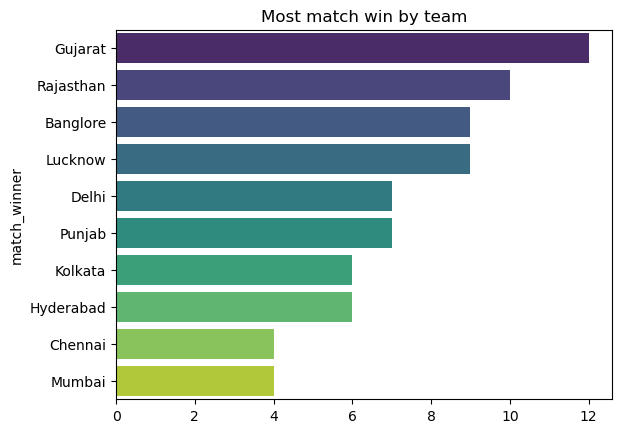

In [14]:
sns.barplot(y = match_wins.index , x = match_wins.values, palette='viridis')
plt.title("Most match win by team")


2. Toss decision trends

Text(0.5, 1.0, 'Toss decision trends')

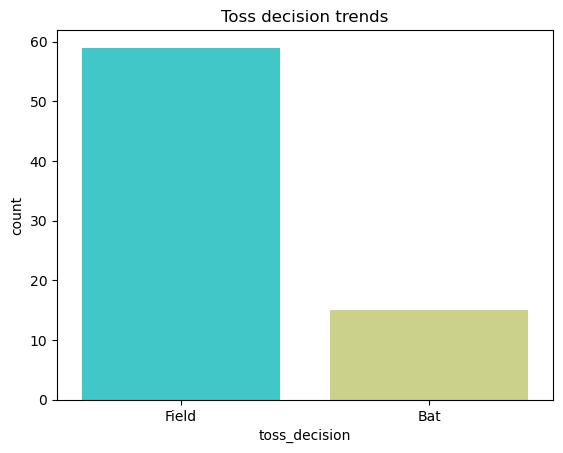

In [16]:
sns.countplot(x = df['toss_decision'],palette='rainbow')
plt.title("Toss decision trends")

3. toss winner vs match winner

In [18]:
count=df[df['toss_winner'] == df["match_winner"]] ['match_id'].count()
percentage = (count*100)/df.shape[0]

In [20]:
percentage.round(2)

np.float64(48.65)

4. How do teams win?(runs/wickets)

Text(0.5, 1.0, 'Won by')

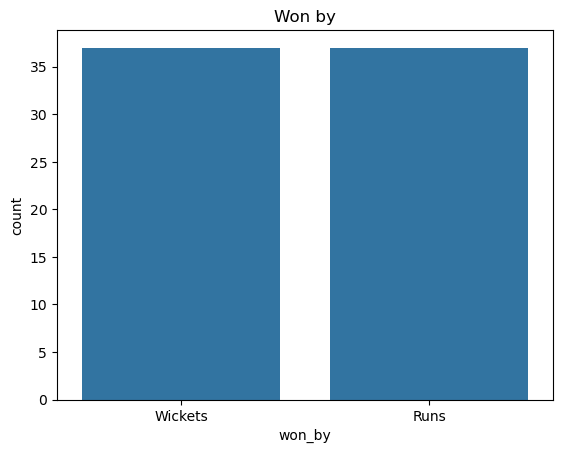

In [22]:
sns.countplot(x = df['won_by'])
plt.title("Won by")

Key player performances

1. most "player of the match" awards

In [26]:
count =df['player_of_the_match'].value_counts().head(10)
count

player_of_the_match
Kuldeep Yadav      4
Jos Buttler        3
Umesh Yadav        2
Quinton de Kock    2
David Miller       2
Umran Malik        2
K L Rahul          2
Rahul Tripathi     2
Hardik Pandya      2
Jasprit Bumrah     2
Name: count, dtype: int64

Text(0.5, 1.0, 'Most player of the match')

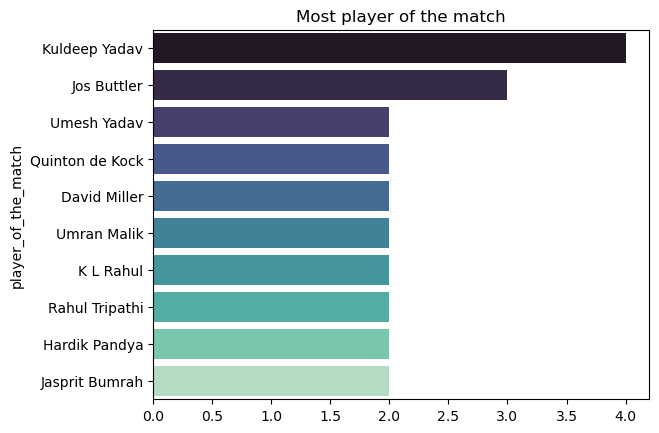

In [29]:
sns.barplot(x=count.values, y = count.index,palette ='mako')
plt.title('Most player of the match')

In [33]:
high = df.groupby("top_scorer") ['highscore'].sum().sort_values(ascending=False).head(2)
high

top_scorer
Jos Buttler        651
Quinton de Kock    377
Name: highscore, dtype: int64

<Axes: ylabel='top_scorer'>

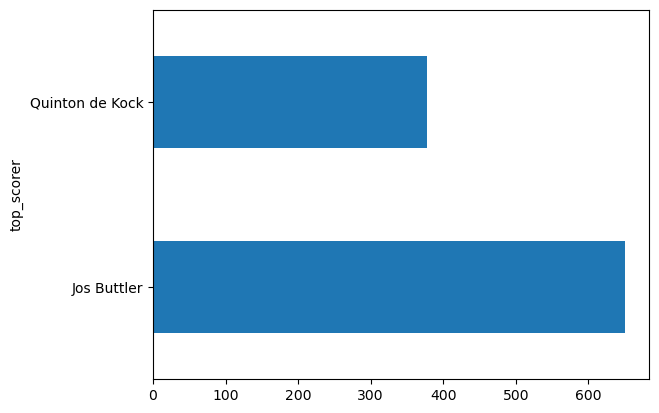

In [35]:
high.plot(kind = 'barh')

10 best bowling figures

In [36]:
df['highest_wickets'] = df['best_bowling_figure'].apply(lambda x: x.split("--")[0])

In [38]:
df['highest_wickets'] =df['highest_wickets'].astype(int)

In [45]:
top_bowlers = df.groupby('best_bowling')["highest_wickets"].sum().sort_values(ascending=False).head(10)
top_bowlers

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wickets, dtype: int64

<Axes: ylabel='best_bowling'>

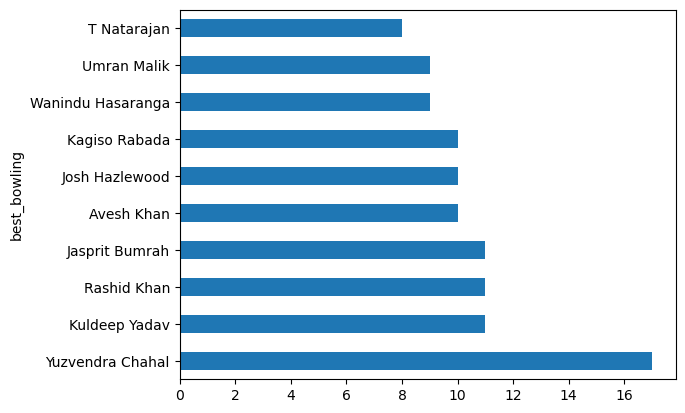

In [46]:
top_bowlers.plot(kind = 'barh')

In [47]:
venue_count = df['venue'].value_counts()
venue_count

venue
Wankhede Stadium, Mumbai                        21
Dr DY Patil Sports Academy, Mumbai              20
Brabourne Stadium, Mumbai                       16
Maharashtra Cricket Association Stadium,Pune    13
Eden Gardens, Kolkata                            2
Narendra Modi Stadium, Ahmedabad                 2
Name: count, dtype: int64

<Axes: ylabel='venue'>

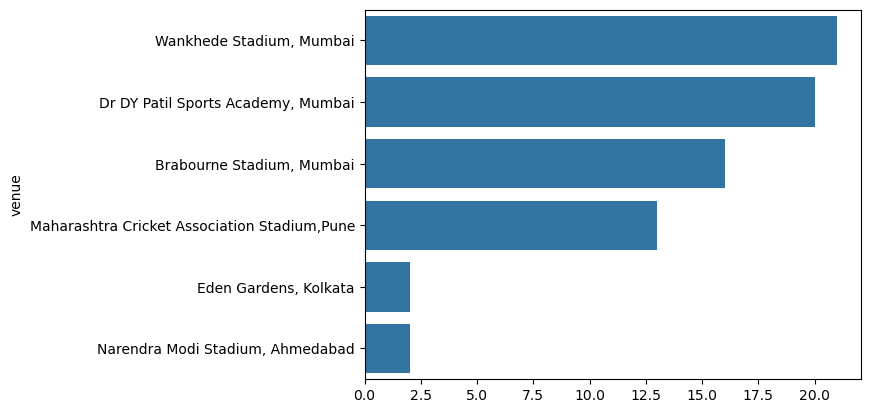

In [49]:
sns.barplot(y =venue_count.index, x = venue_count.values)

Custom questions & insights

1.who won the highest margin by runs?

In [51]:
df[df['won_by']== 'Runs'].sort_values(by = 'margin',ascending = False).head(1)[['match_winner','margin']]

,match_winner,margin
54,Chennai,91


2.which player had the highest individual score?

In [52]:
df[df['highscore']==df['highscore'].max()][['top_scorer','highscore']]

,top_scorer,highscore
65,Quinton de Kock,140


3. which bowler had best bowling figures?

In [54]:
df[df['highest_wickets']==df['highest_wickets'].max()][['best_bowling','best_bowling_figure','highest_wickets']]

,best_bowling,best_bowling_figure,highest_wickets
29,Yuzvendra Chahal,5--40,5
39,Umran Malik,5--25,5
53,Wanindu Hasaranga,5--18,5
55,Jasprit Bumrah,5--10,5
